/Users/alexanderdagher/.pyenv/versions/3.10.12/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/alexanderdagher/.pyenv/versions/3.10.12/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/alexanderdagher/.pyenv/versions/3.10.12/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/alexanderdagher/.pyenv/versions/3.10.12/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported 

Backtest MAE:  1.6066
Backtest RMSE: 3.4917


/Users/alexanderdagher/.pyenv/versions/3.10.12/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/alexanderdagher/.pyenv/versions/3.10.12/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/Users/alexanderdagher/.pyenv/versions/3.10.12/lib/python3.10/site-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.003501. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initia

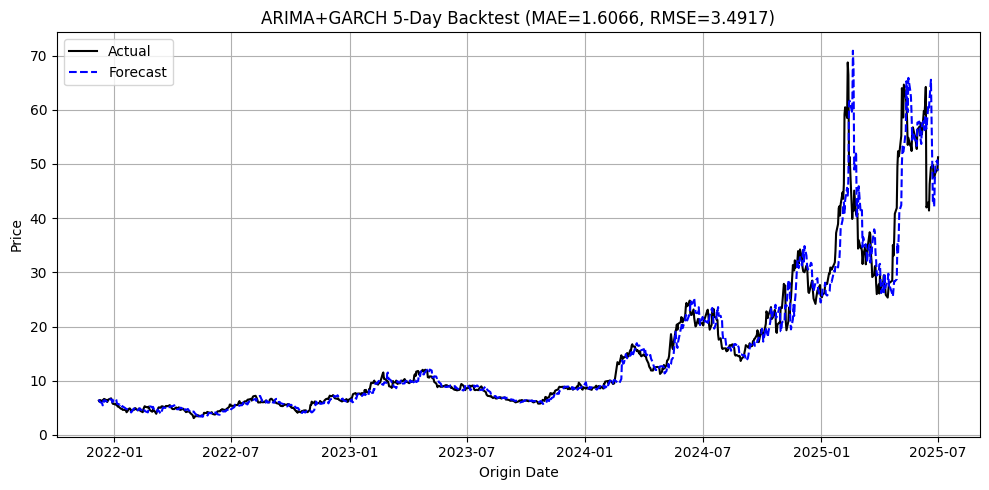


5-Day Forward Forecast:
            ForecastPrice
2025-07-10      51.390978
2025-07-11      51.574576
2025-07-14      51.758356
2025-07-15      51.942797
2025-07-16      52.127896

Saved forward forecast to GOOG_ARIMA_GARCH_forward5.csv


/Users/alexanderdagher/.pyenv/versions/3.10.12/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/alexanderdagher/.pyenv/versions/3.10.12/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/alexanderdagher/.pyenv/versions/3.10.12/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/alexanderdagher/.pyenv/versions/3.10.12/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported 

In [8]:
# === INSTALL IF NEEDED ===
# pip install pandas numpy matplotlib statsmodels arch scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from arch import arch_model
from sklearn.metrics import mean_absolute_error, mean_squared_error

# === CONFIGURATION ===
file_path     = "HIMS_Cleaned.csv"  # path to your cleaned CSV
window_size   = 350                   # days of history for each backtest fit
forecast_days = 5                     # forecast horizon in days

# === STEP 1: Load & preprocess ===
data   = pd.read_csv(file_path, parse_dates=['Date'], index_col='Date')
prices = data['Close']
rets   = np.log(prices / prices.shift(1)).dropna()

# === STEP 2: Rolling backtest (ARIMA+GARCH point forecasts) ===
origins, forecasts, actuals = [], [], []

# We'll stop at len(rets) - forecast_days to ensure we can grab the actual price
for end_ix in range(window_size, len(rets) - forecast_days + 1):
    # 2.1 Train on window ending at end_ix-1, forecast from end_ix
    train = rets[end_ix - window_size : end_ix]
    S0    = prices.iloc[end_ix]

    # 2.2 ARIMA(1,0,0) → forecast next forecast_days log-returns
    arima = sm.tsa.ARIMA(train, order=(1,0,0)).fit()
    mu    = arima.forecast(steps=forecast_days)  # pandas Series or ndarray

    # 2.3 GARCH(1,1) on ARIMA residuals (for σₜ, if you ever need it)
    resid = arima.resid
    g     = arch_model(resid, vol='Garch', p=1, q=1).fit(disp='off')
    g_f   = g.forecast(horizon=forecast_days)
    sigma = np.sqrt(g_f.variance.values[-1])      # array length = forecast_days

    # 2.4 Analytical point forecast at t = forecast_days
    #    Cumulative log-return = sum of mu → convert to price
    mu_vals      = np.asarray(mu)                 # ensure numpy array
    cum_mu       = np.cumsum(mu_vals)
    forecast_pr  = S0 * np.exp(cum_mu[-1])        # positional [-1]
    actual_pr    = prices.iloc[end_ix + forecast_days]

    origins.append(prices.index[end_ix])
    forecasts.append(forecast_pr)
    actuals.append(actual_pr)

backtest_df = pd.DataFrame({
    'Forecast': forecasts,
    'Actual':   actuals
}, index=origins)

# === STEP 2.5: Accuracy metrics ===
mae  = mean_absolute_error(backtest_df['Actual'], backtest_df['Forecast'])
rmse = np.sqrt(mean_squared_error(backtest_df['Actual'], backtest_df['Forecast']))
print(f"Backtest MAE:  {mae:.4f}")
print(f"Backtest RMSE: {rmse:.4f}")

# === STEP 2.6: Plot backtest ===
plt.figure(figsize=(10,5))
plt.plot(backtest_df['Actual'],  label='Actual',  color='black')
plt.plot(backtest_df['Forecast'], label='Forecast', color='blue', linestyle='--')
plt.title(f"ARIMA+GARCH {forecast_days}-Day Backtest (MAE={mae:.4f}, RMSE={rmse:.4f})")
plt.xlabel("Origin Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === STEP 3: Forward Forecast After Last Date ===
train  = rets[-window_size:]
S0     = prices.iloc[-1]

# ARIMA forecast μ₁…μ₅
ar_fwd = sm.tsa.ARIMA(train, order=(1,0,0)).fit()
mu_fwd = ar_fwd.forecast(steps=forecast_days)
mu_vals = np.asarray(mu_fwd)

# (Optional) GARCH forecast σ₁…σ₅
resid_fwd = ar_fwd.resid
g_fwd     = arch_model(resid_fwd, vol='Garch', p=1, q=1).fit(disp='off').forecast(horizon=forecast_days)
sigma_fwd = np.sqrt(g_fwd.variance.values[-1])

# Analytical forward forecast
cum_mu_fwd     = np.cumsum(mu_vals)
forward_prices = S0 * np.exp(cum_mu_fwd)

# Build future dates
future_dates = pd.date_range(
    start=prices.index[-1] + pd.Timedelta(days=1),
    periods=forecast_days,
    freq='B'
)
forward_df = pd.DataFrame({'ForecastPrice': forward_prices}, index=future_dates)

print("\n5-Day Forward Forecast:")
print(forward_df)

# Save to CSV
forward_df.to_csv("GOOG_ARIMA_GARCH_forward5.csv")
print("\nSaved forward forecast to GOOG_ARIMA_GARCH_forward5.csv")
